In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco/hopper'
result_path = '../../../results/mujoco/hopper'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_path}/hopper_baseline_0', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 11
act_ndim = 3
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataloaders = []
nmodel = 5

for _ in range(nmodel):
    dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))


read data shape: torch.Size([40, 918, 14])
read observations shape: torch.Size([40, 918, 11])
read actions shape: torch.Size([40, 918, 3])
shape of observations for training: torch.Size([40, 917, 11])
shape of next observations for training: torch.Size([40, 917, 11])
shape of actions for training: torch.Size([40, 917, 3])


### Training ensemble dynamics

In [3]:
model = example_mujoco.model_ensemble(nmodel, obs_ndim, act_ndim)
example_mujoco.train_ensemble(model, dataloaders, nepoch=300)

0 [array([-0.07868915]), array([-0.08248311]), array([-0.08257967]), array([-0.08405309]), array([-0.0795997])]
10 [array([-0.24673965]), array([-0.26052828]), array([-0.28188596]), array([-0.26969383]), array([-0.24521241])]
20 [array([-0.59314513]), array([-0.62389593]), array([-0.62984939]), array([-0.61456161]), array([-0.59256859])]
30 [array([-0.7656271]), array([-0.80924788]), array([-0.78369331]), array([-0.74879646]), array([-0.78128762])]
40 [array([-0.89956636]), array([-0.65950394]), array([-0.84425831]), array([-0.83280363]), array([-0.72485366])]
50 [array([-0.51049533]), array([-0.93549328]), array([-0.88833847]), array([-0.83183966]), array([-0.88259144])]
60 [array([-0.91596718]), array([-0.95622187]), array([-0.64943795]), array([-0.95866556]), array([-0.90308704])]
70 [array([-0.82912054]), array([-0.96987543]), array([-0.96291561]), array([-0.95776567]), array([-0.50356164])]
80 [array([-0.98139725]), array([-0.95541096]), array([-0.81862202]), array([-1.01104679]),

# Evaluating ensemble baseline

In [4]:
eval_data = util_data.read_datafile(f'{data_path}/hopper_eval_0', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

model.eval()

read evaluation data shape: torch.Size([30, 918, 14])
read evaluation observations shape: torch.Size([30, 918, 11])
read evaluation actions shape: torch.Size([30, 918, 3])


In [5]:
this_traj = 14
deterministic = False
reanchor_nsample = 1_000

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_ensemble(
    model, s0,
    eval_obs[this_traj], eval_act[this_traj],
    deterministic=deterministic, reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 11])


### Plotting rollout results

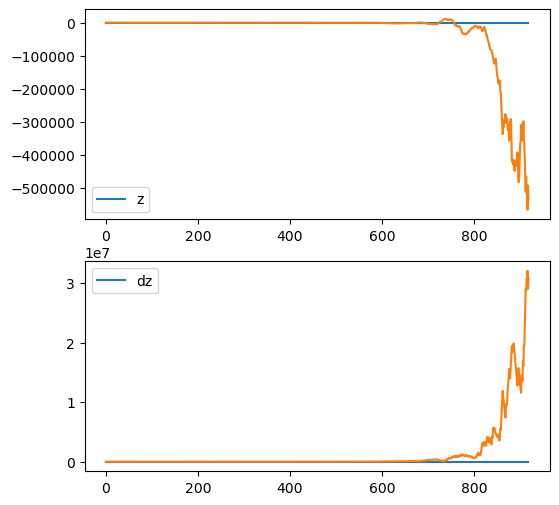

In [6]:
disp_end = rollout_traj.shape[0]
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(f'{result_path}/hopper_ensemble_rollout_{rollout_type}', savedata, delim=' ')

### Analyzing mse vs. rollout horizon

In [7]:
traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_ensemble(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                deterministic=deterministic, reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {eval_obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)

processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 5.419455051422119
	horizon 200 out of 918, loss: 4.121425628662109
	horizon 300 out of 918, loss: 27.58257293701172
	horizon 400 out of 918, loss: 2271.05908203125
	horizon 500 out of 918, loss: 25311.62890625
	horizon 600 out of 918, loss: 27175064.0
	horizon 700 out of 918, loss: 9308302.0
	horizon 800 out of 918, loss: 29483524096.0
	horizon 900 out of 918, loss: 2859380768768.0
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 4.308933258056641
	horizon 200 out of 918, loss: 6.530520439147949
	horizon 300 out of 918, loss: 41.464332580566406
	horizon 400 out of 918, loss: 2963.4609375
	horizon 500 out of 918, loss: 444410.0625
	horizon 600 out of 918, loss: 92379712.0
	horizon 700 out of 918, loss: 22445895680.0
	horizon 800 out of 918, loss: 7132333056.0
	horizon 900 out of 918, loss: 401884807168.0
processing trajectory 3 out of 30
	horizon 100 out of 918, loss: 6.4713454246521
	horizon 200 out of 918

tensor(0.0134)
tensor(0.0201)


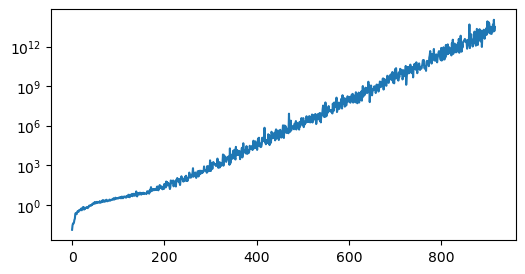

In [8]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.show()

datasaved = False
if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/hopper_ensemble_mse_{rollout_type}', savedata, delim=' ')